# Project 1: Logistic Regression
## This Project gives extra points for the final grade

## **Due 27.11.2025, 16:00**

## Overview

### **Submit your project solution as a group of 2-4 people.**

In this project, you will train a **Logistic Regression** model on a non-linear dataset. The following steps serve as a guide:

### Tasks

1. **Feature Engineering**
   - Since Logistic Regression is a linear classifier, you need to perform feature engineering to make the data linearly separable
   - Consider preprocessing original features
   - Figure out what extra features you should add to the data

2. **Implement Training Loop**
   - Implement the training loop for your Logistic Regression model using **Gradient Descent**
   - Use **BCE Loss** (Binary Cross-Entropy)
   - Incorporate a **regularization** technique to prevent overfitting

3. **Hyperparameter Tuning**
   - Train your model and find good hyperparameters using the **validation set**

4. **Visualization**
   - Visualize the **loss and accuracy curves** of the training process

5. **Testing & Evaluation**
   - Test your trained model on the given **test set**
   - Output the final accuracy rate

### **For full points you need to atleast achieve 73% accuracy on the testing set**

### **NOTE**: 
#### You are not allowed to use sklearn, pytorch or similar Deep Learning frameworks. Numpy is allowed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../data/dataset.csv"
df = pd.read_csv(DATA_PATH)
X = df[["x1", "x2"]].values.astype(float)
y = df["y"].values.astype(int)
print(f"Dataset shape: {X.shape}")
print(f"Classes: {np.unique(y)}")
print(f"\nFirst 5 samples:")
print(df.head())

train_split = int(len(X) * 0.7)      
val_split = int(len(X) * 0.85)       

x_train = X[:train_split]              
x_val = X[train_split:val_split]    
x_test = X[val_split:]  
y_train = y[:train_split]              
y_val = y[train_split:val_split]    
y_test = y[val_split:]
print(f"\nTrain set: {x_train.shape[0]} samples")
print(f"Validation set: {x_val.shape[0]} samples")
print(f"Test set: {x_test.shape[0]} samples")


Dataset shape: (1000, 2)
Classes: [0 1]

First 5 samples:
          x1        x2  y
0   9.492170  0.272589  0
1  16.829156 -0.787517  0
2   0.175471  0.412100  1
3  80.509510 -0.688343  1
4  68.193111  1.447592  0

Train set: 700 samples
Validation set: 150 samples
Test set: 150 samples


In [2]:
def visualize(X, y, title="Data Visualization"):
    cls0 = y == 0
    cls1 = y == 1
    plt.figure()
    plt.scatter(X[cls0, 0], X[cls0, 1], label="y=0", alpha=0.7)
    plt.scatter(X[cls1, 0], X[cls1, 1], label="y=1", alpha=0.7)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

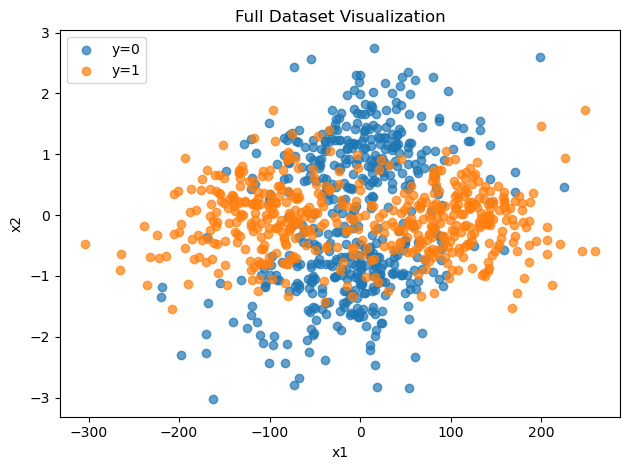

In [3]:
visualize(X, y, title="Full Dataset Visualization")

**(1) Feature Engineering: 2 Points**

Since logistic regression is a linear classifier, one can not expect to perform very well on data that is not linearly seperable. 

Try to figure out how to transform the data, e.g preprocessing original features and adding new features, such that the data becomes linearly seperable.

In [256]:
# TODO: (1) Feature Engineering to prepare data for logistic regression

# x1, x2 features standardization
X_mean = x_train.mean(axis=0)
X_std = x_train.std(axis=0)

x_train_scaled = (x_train - X_mean) / X_std
x_val_scaled = (x_val - X_mean) / X_std
x_test_scaled = (x_test - X_mean) / X_std

def add_polynomial_features(X):
    x1, x2 = X[:,0], X[:,1]
    return np.column_stack([X, x1**2, x2**2, x1*x2])
    #return np.column_stack([x1**2, x2**2])

x_train_poly = add_polynomial_features(x_train_scaled)
x_val_poly = add_polynomial_features(x_val_scaled)
x_test_poly = add_polynomial_features(x_test_scaled)

# Compute mean/std AFTER polynomial expansion (train only)
poly_mean = x_train_poly.mean(axis=0)
poly_std = x_train_poly.std(axis=0)

# Standardize train/val/test using the same stats
x_train_poly = (x_train_poly - poly_mean) / poly_std
x_val_poly = (x_val_poly - poly_mean) / poly_std
x_test_poly = (x_test_poly - poly_mean) / poly_std


In [257]:
x_train_poly

array([[ 0.12864608,  0.3289773 , -0.77769583, -0.66898213,  0.02356861],
       [ 0.21235831, -0.91497092, -0.75512194, -0.12214885, -0.29522355],
       [ 0.02234609,  0.49268221, -0.79038826, -0.56807698, -0.01861683],
       ...,
       [ 0.78261278,  1.91471949, -0.3064421 ,  2.00006652,  1.98539189],
       [-1.48821708, -0.02623384,  0.96063552, -0.74965381,  0.01914962],
       [ 0.52975748, -0.51582832, -0.56885539, -0.55056569, -0.40160589]])

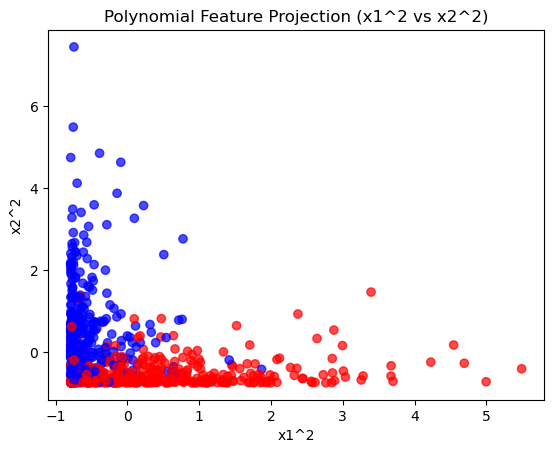

In [258]:
# For visualization, use x1^2 vs x2^2
plt.scatter(x_train_poly[:,2], x_train_poly[:,3], c=y_train, cmap='bwr', alpha=0.7)
plt.xlabel('x1^2')
plt.ylabel('x2^2')
plt.title('Polynomial Feature Projection (x1^2 vs x2^2)')
plt.show()

**(2) Training Logic: 2 Points**

Implement the training logic by finding the best model parameters for logistic regression. Since we have only 2 classes, BCE Loss is a proper loss function. 

Consider implementing regularization to avoid overfitting.

The training loop should take the training set (- and validation set for hyperparameter tuning later), aswell as the hyperparameters, initialize weights and do gradient descent. 

You should track the losses and accuracies throughout the epochs for later visualization.

In [ ]:

# TODO: (2) implement training loop with BCE Loss
# hint: consider regularization to avoid overfitting
# you should return the loss and accuracy values per epoch for later visualization


# These following functions are only meant to be a guideline, you can implement your own versions
def sigmoid(z):
    z = np.clip(z, -50, 50)     # prevent overflow
    return 1 / (1 + np.exp(-z))

def predict(X, W, b):
    return sigmoid(X @ W + b)   # X: (m,n) @ W: (n,) → (m,) + scalar → (m,)

def bce_loss(W, b, X, y, lam=0.0, is_training=True):
    p = predict(X, W, b)
    loss = -np.mean(y * np.log(p + 1e-8) + (1 - y) * np.log(1 - p + 1e-8))  # 1e-8 for numerical stability
    
    # Add L2 regularization ONLY for training
    if is_training and lam > 0:
        loss += lam * np.dot(W, W)
    return loss
    

def grad_bce_with_l2(W, b, X, y, lam=0.0):
    m = len(y)
    p = predict(X, W, b)
    
    # gradients
    dW = (X.T @ (p - y)) / m  + 2 * lam * W     # X.T: (n,m) @ (p - y): (m,) → (n,)
    db = np.mean(p - y)     # scalar
    return dW, db 

def accuracy(y, p):
    y_hat = (p >= 0.5).astype(int)
    return np.mean(y_hat == y)

def train_model(X_tr, y_tr, X_val, y_val, lr=0.1, lam=0.0, epochs=100, random_seed=42):
    
    np.random.seed(random_seed)
    
    n = X_tr.shape[1]   # no_of_features
    
    # Initialization
    W = np.random.normal(0, 0.01, n)  # Small random values
    b = 0.0
    
    train_losses = []
    val_losses = []
    
    train_accs = []
    val_accs = []
    
    # Training loop
    for ep in range(epochs):
        
        # forward & backward
        dW, db = grad_bce_with_l2(W, b, X_tr, y_tr, lam)
        
        # gradient descent update
        W -= lr * dW
        b -= lr * db
        
        # --- tracking losses & accuracies ---
        # training
        tr_loss = bce_loss(W, b, X_tr, y_tr, lam)
        tr_acc = accuracy(y_tr, predict(X_tr, W, b))
        
        # validation
        val_loss = bce_loss(W, b, X_val, y_val, lam, is_training=False)
        val_acc = accuracy(y_val, predict(X_val, W, b))
        
        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        train_accs.append(tr_acc)
        val_accs.append(val_acc)
        
        # logging
        if ep % 20 == 0:
            print(f"Epoch {ep:03d}: Train Loss={tr_loss:.4f}, Val Loss={val_loss:.4f}, Train Acc={tr_acc:.3f}, Val Acc={val_acc:.3f}")
    
    return W, b, train_losses, val_losses, train_accs, val_accs

**(3) Hyperparameter tuning: 0.5 Points**

Your logistic regression model has hyperparameters, e.g. learning rate/regularization lambda, and since there are no  best hyperparameters in general, one has to find them by grid searching through them for the specific model.

Implement the grid search function by going through all possible defined parameters, train the model and evaluate on validation set. 

Save the best hyperparameters and return them.

In [736]:
# TODO: (3) implement hyperparameter tuning

# Fill in learning rates and lambda values to search
lr_list = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1, 0.5]
lambda_list = [0.0, 0.0001, 0.001, 0.01, 0.1, 1.0, 2.0]
def grid_search(X_tr, y_tr, X_val, y_val, lr_list, lambda_list, epochs=100):
    best_lr = None
    best_lambda = None
    best_val_acc = 0
    best_val_loss = np.inf
    
    for lr in lr_list:
        for lam in lambda_list:
            # Train the model for each pair of lr & lam
            _, _, _, val_losses, _, val_accs = train_model(X_tr, y_tr, X_val, y_val, lr, lam, epochs)
            # Get the final validation accuracy (last element in the list)
            final_val_acc = val_accs[-1]
            final_val_loss = val_losses[-1] # 
            print(f"lr={lr:.4f}, lambda={lam:.4f} -> Val Acc={final_val_acc:.4f}, Val loss={final_val_loss:.4f}")
            
            #if final_val_acc > best_val_acc:
            #    best_lr = lr
            #    best_lambda = lam
            #    best_val_acc = final_val_acc
                
            if final_val_loss < best_val_loss:
                best_lr = lr
                best_lambda = lam
                best_val_loss = final_val_loss
                
    #print(f"\nBest Validation Accuracy = {best_val_acc}")
    print(f"\Least Validation Loss = {best_val_loss}")
    return best_lr, best_lambda

In [728]:
# TODO: (3) implement hyperparameter tuning

# Fill in learning rates and lambda values to search
lr_list = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1, 0.5]
lambda_list = [0.0, 0.0001, 0.001, 0.01, 0.1, 1.0, 2.0]
def grid_search(X_tr, y_tr, X_val, y_val, lr_list, lambda_list, epochs=100):
    best_lr = None
    best_lambda = None
    best_val_acc = 0
    best_val_loss = float('inf')
    
    for lr in lr_list:
        for lam in lambda_list:
            # Train the model for each pair of lr & lam
            _, _, _, val_losses, _, val_accs = train_model(X_tr, y_tr, X_val, y_val, lr, lam, epochs)
            
            # Average of last 5 epochs to avoid noise
            final_val_acc = sum(val_accs[-10:]) / 10
            final_val_loss = sum(val_losses[-10:]) / 10 #
            print(f"lr={lr:.4f}, lambda={lam:.4f} -> Val Acc={final_val_acc:.4f}, Val loss={final_val_loss:.4f}")
                            
            if best_lr is None or (final_val_loss <= best_val_loss and final_val_acc >= best_val_acc):
                best_lr = lr
                best_lambda = lam
                best_val_acc = final_val_acc
                best_val_loss = final_val_loss
                
    print(f"\Least Validation Loss = {best_val_loss:.4f}, Best Validation Accuracy = {best_val_acc:.4f}")
    return best_lr, best_lambda

**(4) Training and (5) Testing: 0.5 Points**

- Use grid search to find the best hyperparameters
- train your model with found hyperparameters
- visualize loss and accuracy curves
- test your model on the testing set

In [744]:
# TODO: (4) use grid search to find the best hyperparameters

best_lr, best_lambda = grid_search(x_train_poly, y_train, x_val_poly, y_val, lr_list, lambda_list, epochs=1000)

print(f"Best hyperparameters: lr={best_lr}, lam={best_lambda}")

Epoch 000: Train Loss=0.6951, Val Loss=0.6970, Train Acc=0.404, Val Acc=0.393
Epoch 020: Train Loss=0.6949, Val Loss=0.6967, Train Acc=0.414, Val Acc=0.427
Epoch 040: Train Loss=0.6946, Val Loss=0.6963, Train Acc=0.430, Val Acc=0.433
Epoch 060: Train Loss=0.6943, Val Loss=0.6960, Train Acc=0.443, Val Acc=0.447
Epoch 080: Train Loss=0.6940, Val Loss=0.6956, Train Acc=0.453, Val Acc=0.447
Epoch 100: Train Loss=0.6938, Val Loss=0.6952, Train Acc=0.473, Val Acc=0.467
Epoch 120: Train Loss=0.6935, Val Loss=0.6949, Train Acc=0.491, Val Acc=0.460
Epoch 140: Train Loss=0.6932, Val Loss=0.6945, Train Acc=0.506, Val Acc=0.467
Epoch 160: Train Loss=0.6929, Val Loss=0.6942, Train Acc=0.523, Val Acc=0.473
Epoch 180: Train Loss=0.6927, Val Loss=0.6938, Train Acc=0.539, Val Acc=0.493
Epoch 200: Train Loss=0.6924, Val Loss=0.6935, Train Acc=0.551, Val Acc=0.500
Epoch 220: Train Loss=0.6921, Val Loss=0.6931, Train Acc=0.556, Val Acc=0.513
Epoch 240: Train Loss=0.6918, Val Loss=0.6928, Train Acc=0.573, 

In [745]:
# TODO: train your model with found hyperparameters
W, b, train_losses, val_losses, train_accs, val_accs = train_model(X_tr=x_train_poly, y_tr=y_train, X_val=x_val_poly, y_val=y_val, lr=best_lr, lam=best_lambda, epochs=1000)

Epoch 000: Train Loss=0.6938, Val Loss=0.6953, Train Acc=0.471, Val Acc=0.467
Epoch 020: Train Loss=0.6679, Val Loss=0.6624, Train Acc=0.841, Val Acc=0.800
Epoch 040: Train Loss=0.6453, Val Loss=0.6349, Train Acc=0.857, Val Acc=0.807
Epoch 060: Train Loss=0.6255, Val Loss=0.6118, Train Acc=0.861, Val Acc=0.807
Epoch 080: Train Loss=0.6081, Val Loss=0.5923, Train Acc=0.861, Val Acc=0.800
Epoch 100: Train Loss=0.5928, Val Loss=0.5759, Train Acc=0.861, Val Acc=0.800
Epoch 120: Train Loss=0.5791, Val Loss=0.5620, Train Acc=0.863, Val Acc=0.800
Epoch 140: Train Loss=0.5670, Val Loss=0.5501, Train Acc=0.863, Val Acc=0.800
Epoch 160: Train Loss=0.5561, Val Loss=0.5400, Train Acc=0.863, Val Acc=0.800
Epoch 180: Train Loss=0.5463, Val Loss=0.5312, Train Acc=0.861, Val Acc=0.800
Epoch 200: Train Loss=0.5374, Val Loss=0.5237, Train Acc=0.863, Val Acc=0.800
Epoch 220: Train Loss=0.5294, Val Loss=0.5171, Train Acc=0.861, Val Acc=0.800
Epoch 240: Train Loss=0.5221, Val Loss=0.5114, Train Acc=0.863, 

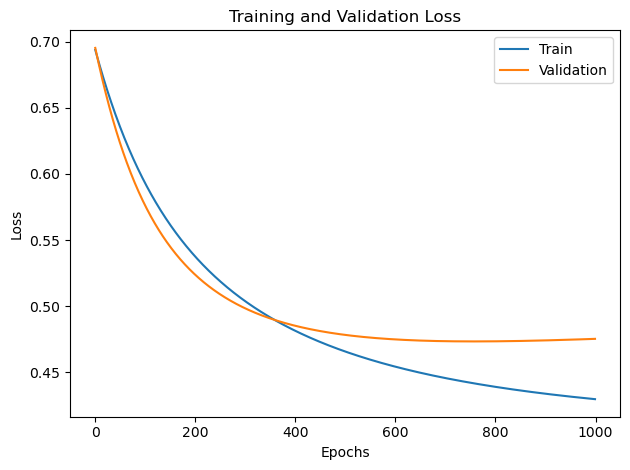

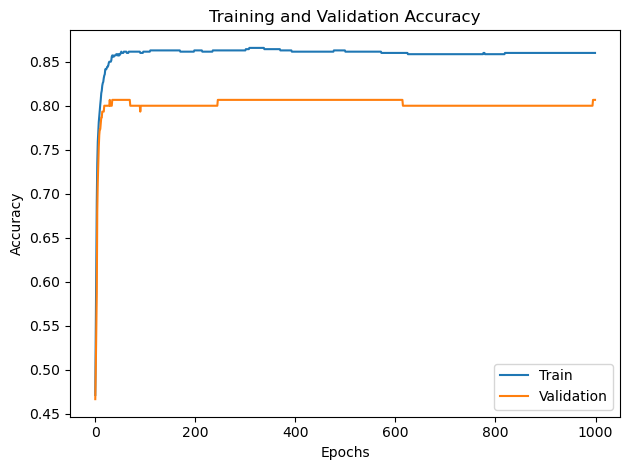

In [746]:
# visualize loss and accuracy curves
def plot_curves(train_values, val_values, ylabel, title):
    plt.figure()
    plt.plot(train_values, label="Train")
    plt.plot(val_values, label="Validation")
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_curves(train_losses, val_losses, ylabel="Loss", title="Training and Validation Loss")
plot_curves(train_accs, val_accs, ylabel="Accuracy", title="Training and Validation Accuracy")

In [747]:
# TODO: (5) test your model on the test set
test_acc = 0
p_test = []
p_test = predict(x_test_poly, W, b)
test_acc = accuracy(y_test, p_test)
print(f"Test accuracy = {test_acc*100}%")

Test accuracy = 76.0%
